**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

### 1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# load the dataset
# noticed that the first column is just an index, so we can skip it
df = pd.read_csv('cars_hw.csv').iloc[:, 1:]
df.head()

,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 976 entries, 0 to 975
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Make               976 non-null    str  
 1   Make_Year          976 non-null    int64
 2   Color              976 non-null    str  
 3   Body_Type          976 non-null    str  
 4   Mileage_Run        976 non-null    int64
 5   No_of_Owners       976 non-null    str  
 6   Seating_Capacity   976 non-null    int64
 7   Fuel_Type          976 non-null    str  
 8   Transmission       976 non-null    str  
 9   Transmission_Type  976 non-null    str  
 10  Price              976 non-null    int64
dtypes: int64(4), str(7)
memory usage: 84.0 KB


Notice that these Columns could all be categorical columns so if I want to use them I would do Dummy variables. 
- Color
- Make
- Make_Year
- Body_Type
- Number of Owners
- Fuel_Type
- Transmission
- Transmission_Type 

These columns are numerical
- Mileage_Run (Could possibly log transformation to bring in the right tale significantly)
- Price (Definitely could use a log transformation because its significantly right skewed)


I think Ill log price and end up keeping Mileage the same because I don't think its as extremely skewed. 

In [4]:
df["Price_log"] = np.log(df["Price"])
df.head()

,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Price_log
0,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,13.395439
1,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,13.432785
2,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,13.583579
3,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,12.933621
4,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,13.151922


### 2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?

In [5]:
groupdf = df.groupby("Make")['Price'].describe().reset_index()
groupdf.head(16)

,Make,count,mean,std,min,25%,50%,75%,max
0,Chevrolet,6.0,4.535000e+05,2.466064e+05,267000.0,288500.0,345500.0,537500.0,892000.0
1,Datsun,3.0,2.896667e+05,1.050397e+04,279000.0,284500.0,290000.0,295000.0,300000.0
2,Ford,52.0,7.211731e+05,1.409277e+05,290000.0,635000.0,707500.0,787000.0,1066000.0
3,Honda,73.0,7.989726e+05,2.665091e+05,316000.0,581000.0,785000.0,915000.0,1537000.0
4,Hyundai,305.0,6.918918e+05,2.791597e+05,248000.0,485000.0,638000.0,837000.0,1742000.0
5,Jeep,4.0,1.499500e+06,1.525134e+05,1290000.0,1447500.0,1529500.0,1581500.0,1649000.0
6,Kia,8.0,1.614750e+06,1.190567e+05,1369000.0,1579000.0,1628500.0,1705750.0,1741000.0
7,MG Motors,35.0,1.869457e+06,1.216611e+05,1589000.0,1786500.0,1848000.0,1978000.0,2019000.0
8,Mahindra,18.0,1.100167e+06,1.755493e+05,796000.0,1037000.0,1094500.0,1157000.0,1465000.0
9,Maruti Suzuki,293.0,5.887850e+05,2.160199e+05,237000.0,411000.0,527000.0,764000.0,1163000.0


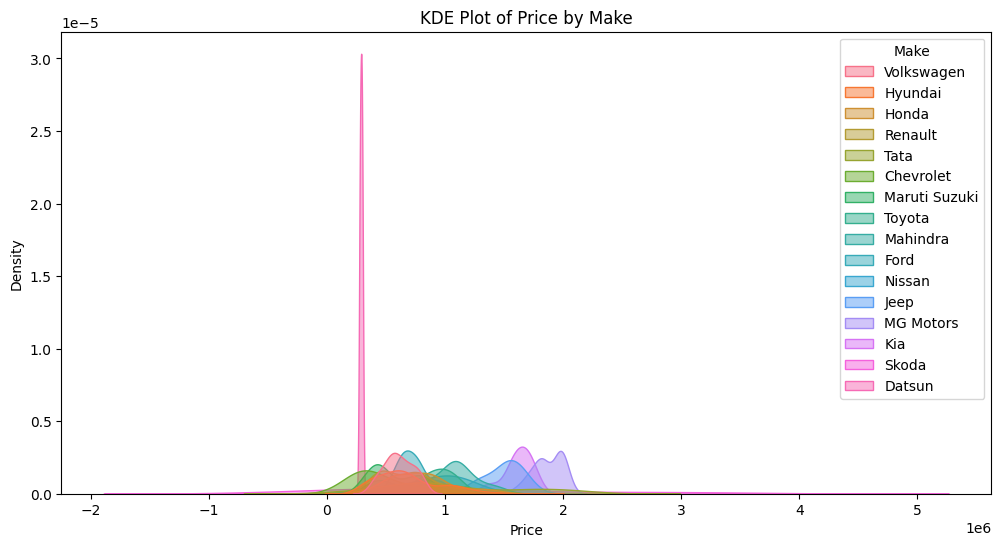

In [6]:
# creating a KDE plot of price and Make to see the distribution of price across different car makes
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x="Price", hue="Make", fill=True, common_norm=False, alpha=0.5)
plt.title("KDE Plot of Price by Make")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()

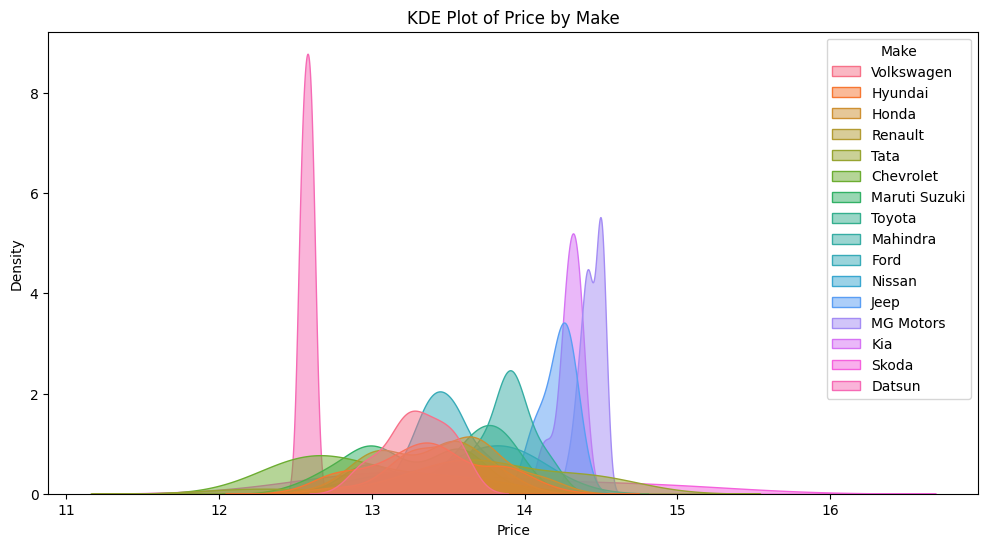

In [7]:
#Kde plot of price and log price grouped by Make
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df, x="Price_log", hue="Make", fill=True, common_norm=False, alpha=0.5)
plt.title("KDE Plot of Price by Make")
plt.xlabel("Price")
plt.ylabel("Density")
plt.show()


**The x-axis is log(Price), so the brands furthest right are most expensive like MG Motors, Jeep, Kia, and Toyota sit at the premium end, while Datsun, Maruti Suzuki, and Tata are the budget options. Datsun stands out with that sharp spike, meaning nearly all their cars are sold at virtually one single price point. Overall the market splits pretty cleanly into two tiers: budget brands around log(12–13) and premium around log(14–15). With most falling in the log 13 15 range.**

### 3. I'll Split the data into an 80% training set and a 20% testing set. For each of the following regressions. 

### 4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set?

In [8]:
x = 'Mileage_Run'
X_simple = df[x].values.reshape(-1, 1).astype(float)  # sklearn expects 2D array for features      
y_target = df["Price_log"]

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_target, test_size=0.2, random_state=42)

# fit the linear regression model with an intercept for training data 
model = LinearRegression(fit_intercept=True).fit(X_train, y_train)   

# make predictions on the test set
y_pred = model.predict(X_test)

# model evaluation 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print('The Root Mean Squared Error Test set is:', rmse)
print('The R-squared value for Test set is: ', r2)
print("The Root Mean Squared Error for the Train set is: ", np.sqrt(mean_squared_error(y_train, model.predict(X_train))))
print("The R-squared value for the Train set is: ", r2_score(y_train, model.predict(X_train)))

The Root Mean Squared Error Test set is: 0.42326661421802125
The R-squared value for Test set is:  0.060558932809053445
The Root Mean Squared Error for the Train set is:  0.44747067536275065
The R-squared value for the Train set is:  0.024143492477947892


### Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set?

In [21]:
# create dummy variables for the categorical variables that I want to include and drop the first category to avoid multicollinearity
df2 = pd.get_dummies(df, columns=["Make","Make_Year","Body_Type","No_of_Owners"], drop_first=True, prefix=["Make", "Make_year", "Body_Type", "No_of_Owners"])

# Dynamically select all dummy variable columns
Make_cols = [col for col in df2.columns if col.startswith("Make_") and not col.startswith("Make_year_")]
Make_year_cols = [col for col in df2.columns if col.startswith("Make_year_")]
Body_Type_cols = [col for col in df2.columns if col.startswith("Body_Type_")]
No_of_Owners_cols = [col for col in df.columns if col.startswith("No_of_Owners_")]


x = Make_cols + Make_year_cols + Body_Type_cols + No_of_Owners_cols
X_simple = df2[x].astype(float)  # sklearn expects 2D array for features      
y_target = df2["Price_log"]

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_target, test_size=0.2, random_state=42)

# fit the linear regression model with an intercept for training data 
model = LinearRegression(fit_intercept=True).fit(X_train, y_train)   

# make predictions on the test set
y_pred = model.predict(X_test)

# model evaluation 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print('The Root Mean Squared Error Test set is:', rmse)
print('The R-squared value for Test set is: ', r2)


The Root Mean Squared Error Test set is: 0.21979199873357827
The R-squared value for Test set is:  0.7466824554878775


### Which model performs better on the test set?

**The categorical model significantly outperforms the numeric-only model on the test set. The categorical model (Make, Make_Year, Body_Type, No_of_Owners) achieves an R² of 0.747 and RMSE of 0.220, compared to the numeric model's R² of only 0.061 and RMSE of 0.423. This represents approximately a 50% reduction in prediction error and explains roughly 12 times more variance. The categorical variables are far more informative for predicting log(Price) than Mileage_Run alone, indicating that car brand, year, body type, and ownership history are stronger price predictors than mileage.**



### Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set?

In [20]:
# create dummy variables for the categorical variables that I want to include and drop the first category to avoid multicollinearity
df3 = pd.get_dummies(df, columns=["Make","Make_Year","Body_Type","No_of_Owners"], drop_first=True, prefix=["Make", "Make_year", "Body_Type", "No_of_Owners"])

# Dynamically select all dummy variable columns
Make_cols = [col for col in df3.columns if col.startswith("Make_") and not col.startswith("Make_year_")]
Make_year_cols = [col for col in df3.columns if col.startswith("Make_year_")]
Body_Type_cols = [col for col in df3.columns if col.startswith("Body_Type_")]
No_of_Owners_cols = [col for col in df.columns if col.startswith("No_of_Owners_")]

# Combine with any other features 
other_features = ["Mileage_Run"]

x = Make_cols + Make_year_cols + Body_Type_cols + No_of_Owners_cols + other_features
X_simple = df3[x].astype(float)     
y_target = df3["Price_log"]

# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_target, test_size=0.2, random_state=42)

# fit the linear regression model with an intercept for training data 
model = LinearRegression(fit_intercept=True).fit(X_train, y_train)   

# make predictions on the test set
y_pred = model.predict(X_test)

# model evaluation 
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)


print('The Root Mean Squared Error Test set is:', rmse)
print('The R-squared value for Test set is: ', r2)

The Root Mean Squared Error Test set is: 0.22024455040109053
The R-squared value for Test set is:  0.745638220038352


### Does the joint model perform better or worse, and by how much?

**The joint model does not improve on the categorical-only model. On the test set, both models produce the same performance (RMSE = 0.220 and (R^2 = 0.746), rounded), so adding Mileage_Run to the categorical features provides essentially no additional predictive power. Relative to the numeric-only model (RMSE = 0.423, (R^2 = 0.061)), both the categorical and joint models are substantially better, cutting prediction error by about 48% and increasing explained variance by about 0.685.**

### 5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?

In [18]:
from sklearn.preprocessing import PolynomialFeatures

# One-hot encode categorical variables
df4 = pd.get_dummies(df, columns=["Make", "Make_Year", "Body_Type", "No_of_Owners"], drop_first=True, prefix=["Make", "Make_year", "Body_Type", "No_of_Owners"])

# Build categorical column lists from df4
Make_cols = [c for c in df4.columns if c.startswith("Make_") and not c.startswith("Make_year_")]
Make_year_cols = [c for c in df4.columns if c.startswith("Make_year_")]
Body_Type_cols = [c for c in df4.columns if c.startswith("Body_Type_")]
No_of_Owners_cols = [c for c in df4.columns if c.startswith("No_of_Owners_")]

cat_cols = Make_cols + Make_year_cols + Body_Type_cols + No_of_Owners_cols
num_col = ["Mileage_Run"]

# Target
y_target = df4["Price_log"]

# Train/test split BEFORE polynomial fit (prevents leakage)
X_train_df, X_test_df, y_train, y_test = train_test_split(
    df4[cat_cols + num_col], y_target, test_size=0.2, random_state=42
)

# Keep categorical dummies as-is
X_train_cat = X_train_df[cat_cols].astype(float).values
X_test_cat = X_test_df[cat_cols].astype(float).values

# Loop over degrees
results = []

for degree in range(1, 23):
    pf = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_num_poly = pf.fit_transform(X_train_df[num_col])
    X_test_num_poly = pf.transform(X_test_df[num_col])

    X_train_final = np.hstack([X_train_cat, X_train_num_poly])
    X_test_final = np.hstack([X_test_cat, X_test_num_poly])

    model = LinearRegression(fit_intercept=True).fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({"Degree": degree, "RMSE": round(rmse, 4), "R2": round(r2, 4)})

# Print results as a table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


 Degree   RMSE      R2
      1 0.2214  0.7430
      2 0.2207  0.7445
      3 0.4264  0.0467
      4 0.4284  0.0378
      5 0.4282  0.0387
      6 0.4260  0.0484
      7 0.4239  0.0577
      8 0.4228  0.0624
      9 0.4228  0.0626
     10 0.4235  0.0595
     11 0.4247  0.0544
     12 0.4261  0.0480
     13 0.4276  0.0411
     14 0.4292  0.0340
     15 0.4308  0.0270
     16 0.4322  0.0206
     17 0.4335  0.0147
     18 0.4346  0.0095
     19 0.4356  0.0051
     20 0.4374 -0.0034
     21 0.4377 -0.0046
     22 0.4380 -0.0058


As degree increases, performance improves a little from degree 1 to 2, then gets much worse after degree 2. Test (R^2) increases slightly from 0.7430 to 0.7445 and RMSE decreases from 0.2214 to 0.2207 at degree 2, but beyond that (R^2) drops and RMSE rises. (R^2) first becomes negative at degree 20.

For your best model with expanded features, what is the $R^2$ and `RMSE`? For our best model with expanded features the R2 is 0.7445 and the RMSE is 0.2207. 

How does it compare to the best model from part 4? I would say the performance is about the same. With the non expanded model performing only slightly better. 
